## General stuff
Guassian:\
$\phi(x) = e^{-\|x\|^2}$

Image function:\
$ f : \mathbb{R}^2 \to \mathbb{R}$

Approximation:\
$ \hat{f}(x) = \sum^n_{i=0}\alpha_i (g_i \triangleright \phi)(y) = \sum^n_{i=0}\alpha_i (\psi(v_i) \triangleright \phi)(y)$

Lie group (dim 6):\
$G = \text{Aff}^+(2)$

Group action on $R^2$:\
For $g \in G, y \in R^2$ then $g \triangleright y = (x, A) \triangleright y := Ay + x$

For $f : \mathbb{R}^2 \to \mathbb{R}$ then $(g \triangleright f)(y) := f(g^{-1} \triangleright y)$ 

Parameter space (dim 6):\
$V = \mathbb{R}^2 \times \text{SO}(2) \times \text{SNM}(2)$

Mapping:\
$\psi : V \to G$\
$\psi(L, X, Y) = (L, \exp(X)\exp(Y))$

For $X = \begin{pmatrix}
0 & b \\
-b & 0
\end{pmatrix}$ then $\exp(X) = \begin{pmatrix}
\cos(b) & \sin(b) \\
-\sin(b) & \cos(b)
\end{pmatrix}$

For
$
Y=\begin{pmatrix}a & b \\ b & c\end{pmatrix},
$
define
$
m=\tfrac{a+c}{2}, \quad 
B = Y - mI = \begin{pmatrix}\tfrac{a-c}{2} & b \\[4pt] b & -\tfrac{a-c}{2}\end{pmatrix}, \quad 
s=\sqrt{b^{2}+\left(\tfrac{a-c}{2}\right)^{2}}.
$

Then
$
\exp(Y) \;=\; e^{\,m}\!\left( \cosh(s)\,I + \frac{\sinh(s)}{s}\,B \right).
$

Loss:\
$\mathcal{L} = \|f-\hat{f}\|_{L^2}$

In [117]:
import torch
import numpy as np
import math

In [118]:
# Group actions

def group_action(x: torch.Tensor, A: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    return torch.einsum('bjk,bk->bj', A, y) + x

def group_action_inv(x: torch.Tensor, A: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    return torch.einsum('bjk,bk->bj', torch.linalg.inv(A), y - x)

def group_action_func(x: torch.Tensor, A: torch.Tensor, y: torch.Tensor, f: callable) -> torch.Tensor:
    y_inv = group_action_inv(x, A, y)
    return f(y_inv)

In [119]:
# Mapping from parametric space to lie group

# Map exp of the theta of a 2x2 anti symmetric matrix to explicit
def exp_SO(theta: torch.Tensor) -> torch.Tensor:
    return torch.stack([torch.stack([torch.cos(theta), -torch.sin(theta)]),
                         torch.stack([torch.sin(theta), torch.cos(theta)])]).permute(2, 0, 1)

# Map exp of 2x2 symmetric matrix to explicit
def exp_SNM(A: torch.Tensor) -> torch.Tensor:
    a, b = A[..., 0, 0], A[..., 0, 1]
    c = A[..., 1, 1]

    m = 0.5 * (a + c)

    # Define B = A - mI
    B00 = 0.5 * (a - c)
    B01 = b
    B10 = b
    B11 = -0.5 * (a - c)

    # Compute s = sqrt(b^2 + ((a-c)/2)^2)
    eps = 1e-8 # counteract floating point inprecision
    s = torch.sqrt(b**2 + (0.5 * (a - c))**2)

    # Handle s=0 case with safe division
    sinhc = torch.where(s > 1e-12, torch.sinh(s) / s, torch.ones_like(s))

    # exp(A) = exp(m) * (cosh(s) * I + (sinh(s)/s) * B)
    expm = torch.zeros_like(A)
    expm[..., 0, 0] = torch.cosh(s) + sinhc * B00
    expm[..., 0, 1] = sinhc * B01
    expm[..., 1, 0] = sinhc * B10
    expm[..., 1, 1] = torch.cosh(s) + sinhc * B11

    return torch.exp(m)[..., None, None] * expm




In [178]:
# gaussian

def gaussian(y: torch.Tensor):
    norm = torch.linalg.vector_norm(y, dim=1)
    return torch.exp(-1 * torch.pow(norm, 2))

def f_hat(w: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    # calc all parameters
    alpha = w[0]
    a = w[1]
    b = w[2]
    c = w[3]
    theta = w[4]
    x1 = w[5]
    x2 = w[6]

    Y = torch.stack([torch.stack([a, b]), torch.stack([b, c])]).permute(2, 0, 1)

    A = torch.bmm(exp_SO(theta), exp_SNM(Y))
    x = torch.stack([x1, x2]).permute(1, 0)

    return torch.sigmoid(alpha) * group_action_func(x, A, y, gaussian)


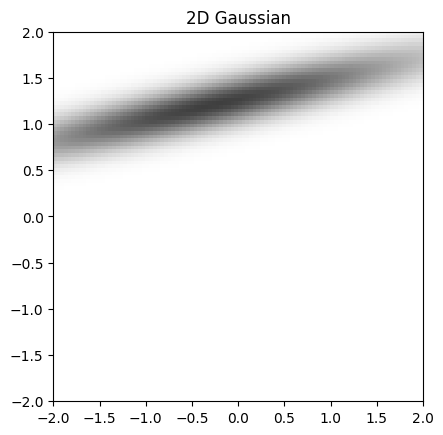

In [121]:

# plot 2D image of gaussian function

import matplotlib.pyplot as plt

# Create a grid of points
xv, yv = np.meshgrid(np.linspace(-2, 2, 100), np.linspace(-2, 2, 100))
points = np.stack([xv, yv], axis=-1)  # shape (100, 100, 2)

x = torch.tensor([-0.2805,1.2112])
# 1.1102,  0.7595, -0.3787, -1.3284,  0.3944, -0.2805,  1.2112

a = torch.tensor([0.7595])
b = torch.tensor([-0.3787])
c = torch.tensor([-1.3284])
theta = torch.tensor([0.3944])

Y = torch.tensor([[a, b], [b, c]], dtype=torch.float)

# Evaluate gaussian at each point
gauss_img = np.zeros((100, 100))
for i in range(100):
	for j in range(100):
		gauss_img[i, j] = torch.sigmoid(torch.tensor(1.1102))*group_action_func(x, exp_SO(theta) @ exp_SNM(Y), torch.tensor([points[i, j]], dtype=torch.float), gaussian)

plt.title("2D Gaussian")
plt.imshow(1 - gauss_img, extent=[-2, 2, -2, 2], origin='lower', cmap='gray', vmin=0, vmax=1)
plt.show()

In [317]:

torch.autograd.set_detect_anomaly(False)

device = torch.device("cuda:0")

def train(learning_rate, epochs, batches, target):
    # Prepare training data as a batch for vectorized computation
    inputs = torch.stack([torch.tensor([i, j], dtype=torch.float, device=device) for i in range(-2, 3) for j in range(-2, 3)])  # shape (25, 2)
    targets = torch.stack([target.flatten()]*batches)  # shape (25, )

    w = torch.randn(7, batches, requires_grad=True, device=device)

    for epoch in range(epochs):
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}")
            
        # Vectorized forward pass
        preds = torch.stack([
            f_hat(w, torch.stack([x] * batches)) for x in inputs
        ]).permute(1, 0) 

        eps = 1e-18 # counteract floating point inprecision
        
        loss = torch.sqrt(torch.sum((targets - preds)**2, 1)  + eps).mean()
        loss.backward()
        with torch.no_grad():
            if (epoch + 1) % 10 == 0:
                print(w.grad.sum(1))
            w -= learning_rate * w.grad
        w.grad.zero_()

    preds = torch.stack([f_hat(w, torch.stack([x] * batches)) for x in inputs]).permute(1, 0)
    loss = torch.sqrt(torch.sum((targets - preds)**2, 1))

    return loss, w

In [217]:
# plot 2D image of gaussian function
def plot_image(w: torch.Tensor, resolution=25):
    w = w.to(torch.device("cpu"))
    # Create a grid of points
    xv, yv = np.meshgrid(np.linspace(-2, 2, resolution), np.linspace(-2, 2, resolution))
    points = torch.tensor(np.stack([xv, yv], axis=-1), dtype=torch.float)  # shape (100, 100, 2)

    print(torch.stack([w]))
    # Evaluate gaussian at each point
    gauss_img = np.zeros((resolution, resolution))
    for i in range(0, resolution):
        for j in range(0, resolution):
            gauss_img[i, j] = f_hat(w.unsqueeze(1), torch.stack([points[i, j]]))

    plt.title("2D Gaussian")
    plt.imshow(1-gauss_img, origin='lower', cmap='gray', vmin=0, vmax=1)
    plt.show()

In [314]:
learning_rate = 1
epochs = 500
batches = 5

# create a 4x4 tensor with all the same value a=0.3
a = 0.5
output_z = torch.full((5, 5), a, device=device)

loss, w = train(learning_rate, epochs, batches, output_z)

min_index = torch.argmin(loss)



torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
Epoch 10/500
torch.Size([25])
tensor([-0.0208, -0.0255, -0.0166, -0.0272, -0.1711,  0.0158, -0.0131],
       device='cuda:0')
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
Epoch 20/500
torch.Size([25])
tensor([-0.0218, -0.0530, -0.0264, -0.0060, -0.0527, -0.0195,  0.0182],
       device='cuda:0')
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
Epoch 30/500
torch.Size([25])
tensor([-0.0205, -0.0309, -0.0129, -0.0365,  0.1711, -0.0081,  0.0060],
       device='cuda:0')
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
torch.Size([25])
Epoch 40/5

KeyboardInterrupt: 

In [219]:
print(loss)
inputs = torch.stack([torch.tensor([i, j], dtype=torch.float, device=device) for i in range(-2, 3) for j in range(-2, 3)])
preds = torch.stack([
    f_hat(w, torch.stack([x] * batches)) for x in inputs
]).permute(1, 0) 
print(preds)

tensor([0.2748, 0.2558, 0.4111, 0.0490, 0.3832], device='cuda:0',
       grad_fn=<SqrtBackward0>)
tensor([[0.5046, 0.5103, 0.5114, 0.5078, 0.4995, 0.5118, 0.5178, 0.5190, 0.5153,
         0.5070, 0.5138, 0.5199, 0.5211, 0.5176, 0.5094, 0.5104, 0.5165, 0.5179,
         0.5145, 0.5063, 0.5017, 0.5078, 0.5093, 0.5060, 0.4981],
        [0.4799, 0.4876, 0.4902, 0.4874, 0.4793, 0.4874, 0.4953, 0.4979, 0.4951,
         0.4870, 0.4898, 0.4978, 0.5004, 0.4977, 0.4895, 0.4869, 0.4949, 0.4976,
         0.4948, 0.4868, 0.4788, 0.4867, 0.4894, 0.4868, 0.4789],
        [0.5055, 0.5139, 0.5172, 0.5151, 0.5079, 0.5133, 0.5218, 0.5250, 0.5229,
         0.5155, 0.5157, 0.5241, 0.5273, 0.5251, 0.5176, 0.5125, 0.5209, 0.5240,
         0.5218, 0.5142, 0.5040, 0.5122, 0.5151, 0.5129, 0.5054],
        [0.5068, 0.5055, 0.5018, 0.4956, 0.4871, 0.5059, 0.5060, 0.5038, 0.4990,
         0.4919, 0.5023, 0.5039, 0.5031, 0.4998, 0.4941, 0.4961, 0.4992, 0.4998,
         0.4980, 0.4937, 0.4874, 0.4919, 0.4939, 0.4936,

tensor([[ 0.0273,  3.3804,  0.1320,  2.7891,  0.6057, -1.7814, -1.8841]],
       grad_fn=<StackBackward0>)


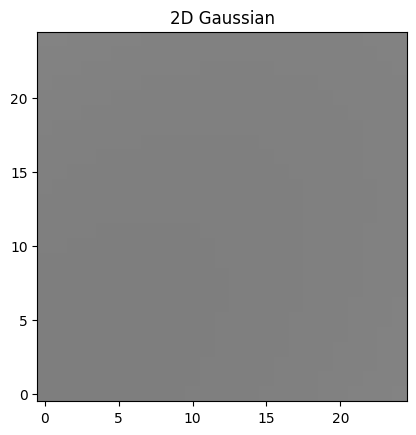

In [220]:
plot_image(w[:, min_index], 25)

In [334]:
learning_rate = 0.1
epochs = 200
batches = 1000

# create a 5x5 with a black stripe in the middle
output_z = torch.stack([torch.tensor([0]*5), torch.tensor([0]*5), torch.tensor([1]*5), torch.tensor([0]*5), torch.tensor([0]*5)]).to(device)

print(output_z)

loss, w = train(learning_rate, epochs, batches, output_z)

print(loss)
min_index = torch.argmin(loss)

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], device='cuda:0')
Epoch 10/200
tensor([ 0.0057, -0.0171, -0.0077, -0.0231,  0.0130,  0.0016, -0.0079],
       device='cuda:0')
Epoch 20/200
tensor([ 0.0055, -0.0172, -0.0075, -0.0231,  0.0137,  0.0003, -0.0078],
       device='cuda:0')
Epoch 30/200
tensor([ 0.0052, -0.0174, -0.0074, -0.0231,  0.0142, -0.0010, -0.0080],
       device='cuda:0')
Epoch 40/200
tensor([ 0.0049, -0.0175, -0.0072, -0.0230,  0.0134, -0.0022, -0.0085],
       device='cuda:0')
Epoch 50/200
tensor([ 0.0046, -0.0177, -0.0070, -0.0229,  0.0115, -0.0033, -0.0091],
       device='cuda:0')
Epoch 60/200
tensor([ 0.0044, -0.0177, -0.0067, -0.0229,  0.0102, -0.0036, -0.0086],
       device='cuda:0')
Epoch 70/200
tensor([ 0.0041, -0.0177, -0.0064, -0.0230,  0.0100, -0.0033, -0.0072],
       device='cuda:0')
Epoch 80/200
tensor([ 0.0039, -0.0177, -0.0061, -0.0230,  0.0097, -0.0031, -0.0057],
       de

tensor(1.0522, device='cuda:0', grad_fn=<SelectBackward0>)
tensor([[ 0.3465,  1.0700,  1.5898, -0.6647,  1.0600, -0.0326, -0.1683]],
       grad_fn=<StackBackward0>)


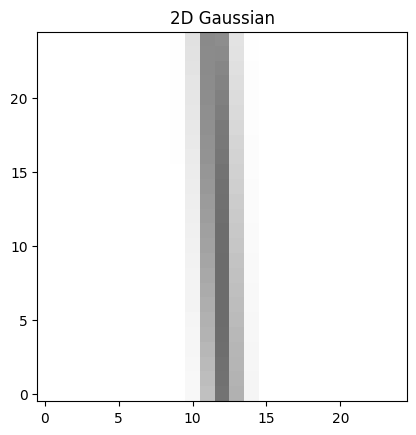

In [335]:
print(loss[min_index])

plot_image(w[:, min_index], 25)

In [ ]:
learning_rate = 1
epochs = 100
batches = 5

# create a 4x4 tensor with all the same value a=0.3
output_z = torch.stack([torch.tensor([1]*5), torch.tensor([1]*5), torch.tensor([1]*5), torch.tensor([0]*5), torch.tensor([0]*5)]).to(device)

print(output_z)

loss, w = train(learning_rate, epochs, batches, output_z)

print(loss)
min_index = torch.argmin(loss)

tensor([[1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], device='cuda:0')
Epoch 10/1000
tensor([-0.0002,  0.0463,  0.0266,  0.0354,  0.0099], device='cuda:0')
Epoch 20/1000
tensor([-0.0002,  0.0332,  0.0339,  0.0229,  0.0116], device='cuda:0')
Epoch 30/1000
tensor([-0.0002,  0.0242, -0.0029,  0.0159,  0.0135], device='cuda:0')
Epoch 40/1000
tensor([-0.0002,  0.0184, -0.0089,  0.0131,  0.0157], device='cuda:0')
Epoch 50/1000
tensor([-0.0002,  0.0151, -0.0097,  0.0127,  0.0168], device='cuda:0')
Epoch 60/1000
tensor([-0.0002,  0.0133, -0.0098,  0.0135,  0.0163], device='cuda:0')
Epoch 70/1000
tensor([-0.0002,  0.0123, -0.0097,  0.0148,  0.0147], device='cuda:0')
Epoch 80/1000
tensor([-0.0002,  0.0117, -0.0097,  0.0158,  0.0122], device='cuda:0')
Epoch 90/1000
tensor([-0.0002,  0.0115, -0.0096,  0.0165,  0.0089], device='cuda:0')
Epoch 100/1000
tensor([-0.0002,  0.0118, -0.0096,  0.0167,  0.0051], device='cuda:0')
Epoch 

tensor([[ 1.5115,  0.4858, -0.4567,  1.7892, -0.3014, -1.3595, -0.3197]],
       grad_fn=<StackBackward0>)


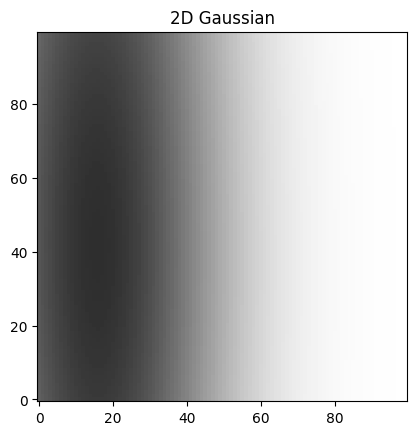

In [215]:
plot_image(w[:, min_index], 100)